# 04 — Model Comparison: Decision Tree & Random Forest
**Project:** California Property Close Price Prediction — IDX Exchange SU26
**Author:** Anvith Mulpuri
**Week:** 5 of 12
**Input:** `sfr_baseline_train.csv` / `sfr_baseline_test.csv` (raw fields only, no engineered features)
**Experiment IDs:** Decision Tree A, Random Forest A

---

## Scope Note

Per project convention, this notebook uses **only the baseline (no-engineered-feature) dataset**
— the same 10 raw fields as Linear Regression A. Feature engineering, encoding of high-
cardinality categoricals, and scaling are intentionally deferred to Week 6, so that any
performance difference seen here is attributable to the **model type**, not a richer feature
set. This isolates the question: "how much can a different algorithm alone improve on the
same information Linear Regression A had?"

## Standardized Evaluation Methodology (unchanged from Week 4)
- Same chronological split: train = 6 months preceding test month, test = latest full month (May 2026)
- Same leakage exclusions: `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, `PriceReductionYN` excluded
- Same outlier thresholds: learned from train only (0.5th/99.5th percentile ClosePrice)
- Same headline metrics: R², MAPE, MdAPE, MAE reported together for every model

## Notebook Goals
- Load the same baseline train/test split used in `03_baseline_model.ipynb`
- Train a Decision Tree Regressor (Decision Tree A)
- Train a Random Forest Regressor (Random Forest A)
- Compare both against Linear Regression A on R², MAPE, MdAPE, MAE
- Document each model's behavior — strengths, weaknesses, and why
- Append both experiments to `experiment_log.csv`

### Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
# ── Load the SAME baseline split used in 03_baseline_model.ipynb ──
# No engineered features, no encodings, no scaling -- per project convention,
# this stays true until Week 6.
CLEANED_DIR = Path('../data/cleaned')

train_df = pd.read_csv(CLEANED_DIR / 'sfr_baseline_train.csv', low_memory=False)
test_df  = pd.read_csv(CLEANED_DIR / 'sfr_baseline_test.csv', low_memory=False)

print(f'Train shape: {train_df.shape}')
print(f'Test shape : {test_df.shape}')

Train shape: (58805, 63)
Test shape : (11909, 63)


In [4]:
# ── Same baseline feature set as Linear Regression A ─────────────
# Raw fields only. Excludes ListPrice/OriginalListPrice/DaysOnMarket/
# PriceReductionYN per the leakage audit, and excludes high-cardinality
# categoricals since encoding them counts as feature engineering (Week 6).
BASELINE_FEATURES = [
    'LivingArea',
    'LotSizeSquareFeet',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'Stories',
    'YearBuilt',
    'GarageSpaces',
    'ParkingTotal',
    'Latitude',
    'Longitude',
]

TARGET = 'ClosePrice'

# Same residual-null handling as 03_baseline_model.ipynb (a handful of rows
# have nulls in Latitude/Longitude/BathroomsTotalInteger not covered by the
# Week 3 imputation plan)
before_train, before_test = len(train_df), len(test_df)
train_clean = train_df.dropna(subset=BASELINE_FEATURES + [TARGET])
test_clean  = test_df.dropna(subset=BASELINE_FEATURES + [TARGET])
print(f'Train: {before_train:,} -> {len(train_clean):,} rows')
print(f'Test : {before_test:,} -> {len(test_clean):,} rows')

X_train = train_clean[BASELINE_FEATURES].copy()
y_train = train_clean[TARGET].copy()
X_test  = test_clean[BASELINE_FEATURES].copy()
y_test  = test_clean[TARGET].copy()

print(f'\nX_train: {X_train.shape}  |  X_test: {X_test.shape}')

Train: 58,805 -> 58,797 rows
Test : 11,909 -> 11,907 rows

X_train: (58797, 10)  |  X_test: (11907, 10)


In [5]:
# ── Shared evaluation function (identical to 03_baseline_model.ipynb) ──
def mdape(y_true, y_pred):
    '''Median Absolute Percentage Error -- robust to outliers, unlike MAPE.'''
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(y_true, y_pred, label=''):
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mdape_val = mdape(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))

    print(f'{label} Evaluation:')
    print(f'  R²     : {r2:.4f}')
    print(f'  MAPE   : {mape:.2f}%')
    print(f'  MdAPE  : {mdape_val:.2f}%   <-- primary metric (robust to skew/outliers)')
    print(f'  MAE    : ${mae:,.0f}')

    return {'r2': r2, 'mape': mape, 'mdape': mdape_val, 'mae': mae}

In [6]:
# ── Load Linear Regression A's test metrics for direct comparison ──
# Pulled from the experiment log saved in 03_baseline_model.ipynb
experiment_log = pd.read_csv('../deliverables/experiment_log.csv')
lr_a = experiment_log[experiment_log['experiment_id'] == 'Linear Regression A'].iloc[0]

print('Linear Regression A (Week 4 baseline) -- for comparison:')
print(f"  R²    : {lr_a['r2_test']:.4f}")
print(f"  MAPE  : {lr_a['mape_test']:.2f}%")
print(f"  MdAPE : {lr_a['mdape_test']:.2f}%")
print(f"  MAE   : \${lr_a['mae_test']:,.0f}")

Linear Regression A (Week 4 baseline) -- for comparison:
  R²    : 0.4733
  MAPE  : 43.73%
  MdAPE : 30.60%
  MAE   : \$462,823


<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_68215/435409615.py:10: SyntaxWarning: invalid escape sequence '\$'
  print(f"  MAE   : \${lr_a['mae_test']:,.0f}")


---
## 1. Decision Tree Regressor (Decision Tree A)

A single decision tree splits the feature space into rectangular regions, predicting the
average `ClosePrice` within each region. Unlike Linear Regression, it can capture non-linear
relationships and interactions between features (e.g. the effect of `LivingArea` on price
can differ by `Latitude`/`Longitude` region) without needing those interactions engineered
by hand.

A modest `max_depth` is used to start — an unconstrained tree will memorize the training data
(near-perfect train R², poor generalization to test).

In [7]:
dt_model = DecisionTreeRegressor(
    max_depth=8,             # constrained depth -- prevents memorizing training data
    min_samples_leaf=20,     # each leaf must represent at least 20 real transactions
    random_state=RANDOM_SEED
)
dt_model.fit(X_train, y_train)

y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt  = dt_model.predict(X_test)

print('Decision Tree A trained.')
print(f'Tree depth actually used: {dt_model.get_depth()}')
print(f'Number of leaves: {dt_model.get_n_leaves()}')

Decision Tree A trained.
Tree depth actually used: 8
Number of leaves: 186


In [8]:
print('=' * 55)
dt_train_metrics = evaluate_model(y_train, y_train_pred_dt, label='Decision Tree A -- TRAIN')
print()
print('=' * 55)
dt_test_metrics = evaluate_model(y_test, y_test_pred_dt, label='Decision Tree A -- TEST')
print('=' * 55)

Decision Tree A -- TRAIN Evaluation:
  R²     : 0.7131
  MAPE   : 26.49%
  MdAPE  : 18.61%   <-- primary metric (robust to skew/outliers)
  MAE    : $303,977

Decision Tree A -- TEST Evaluation:
  R²     : 0.6785
  MAPE   : 26.32%
  MdAPE  : 18.58%   <-- primary metric (robust to skew/outliers)
  MAE    : $327,165


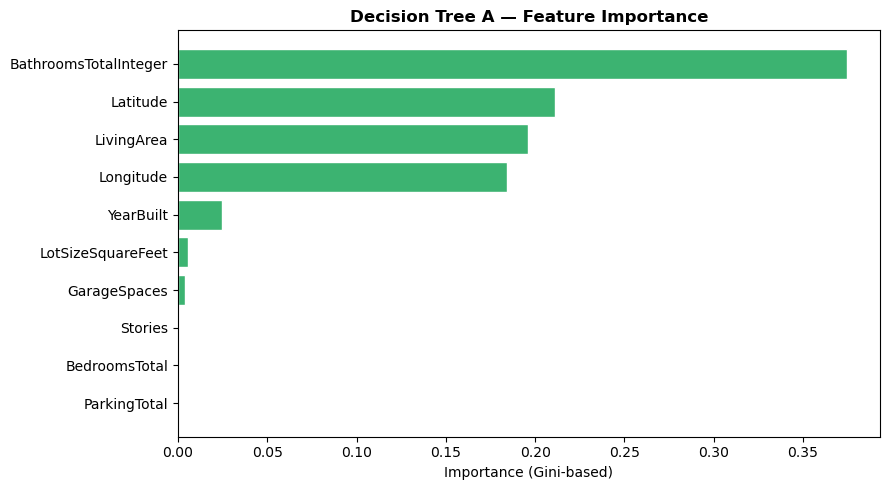

,feature,importance
3,BathroomsTotalInteger,0.374358
8,Latitude,0.210843
0,LivingArea,0.196051
9,Longitude,0.184067
5,YearBuilt,0.024757
1,LotSizeSquareFeet,0.005601
6,GarageSpaces,0.004159
4,Stories,0.000165
2,BedroomsTotal,0.000000
7,ParkingTotal,0.000000


In [9]:
# Feature importance -- which raw fields the tree actually splits on
dt_importance = pd.DataFrame({
    'feature': BASELINE_FEATURES,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(dt_importance['feature'][::-1], dt_importance['importance'][::-1],
        color='mediumseagreen', edgecolor='white')
ax.set_title('Decision Tree A — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance (Gini-based)')
plt.tight_layout()
plt.show()

display(dt_importance)

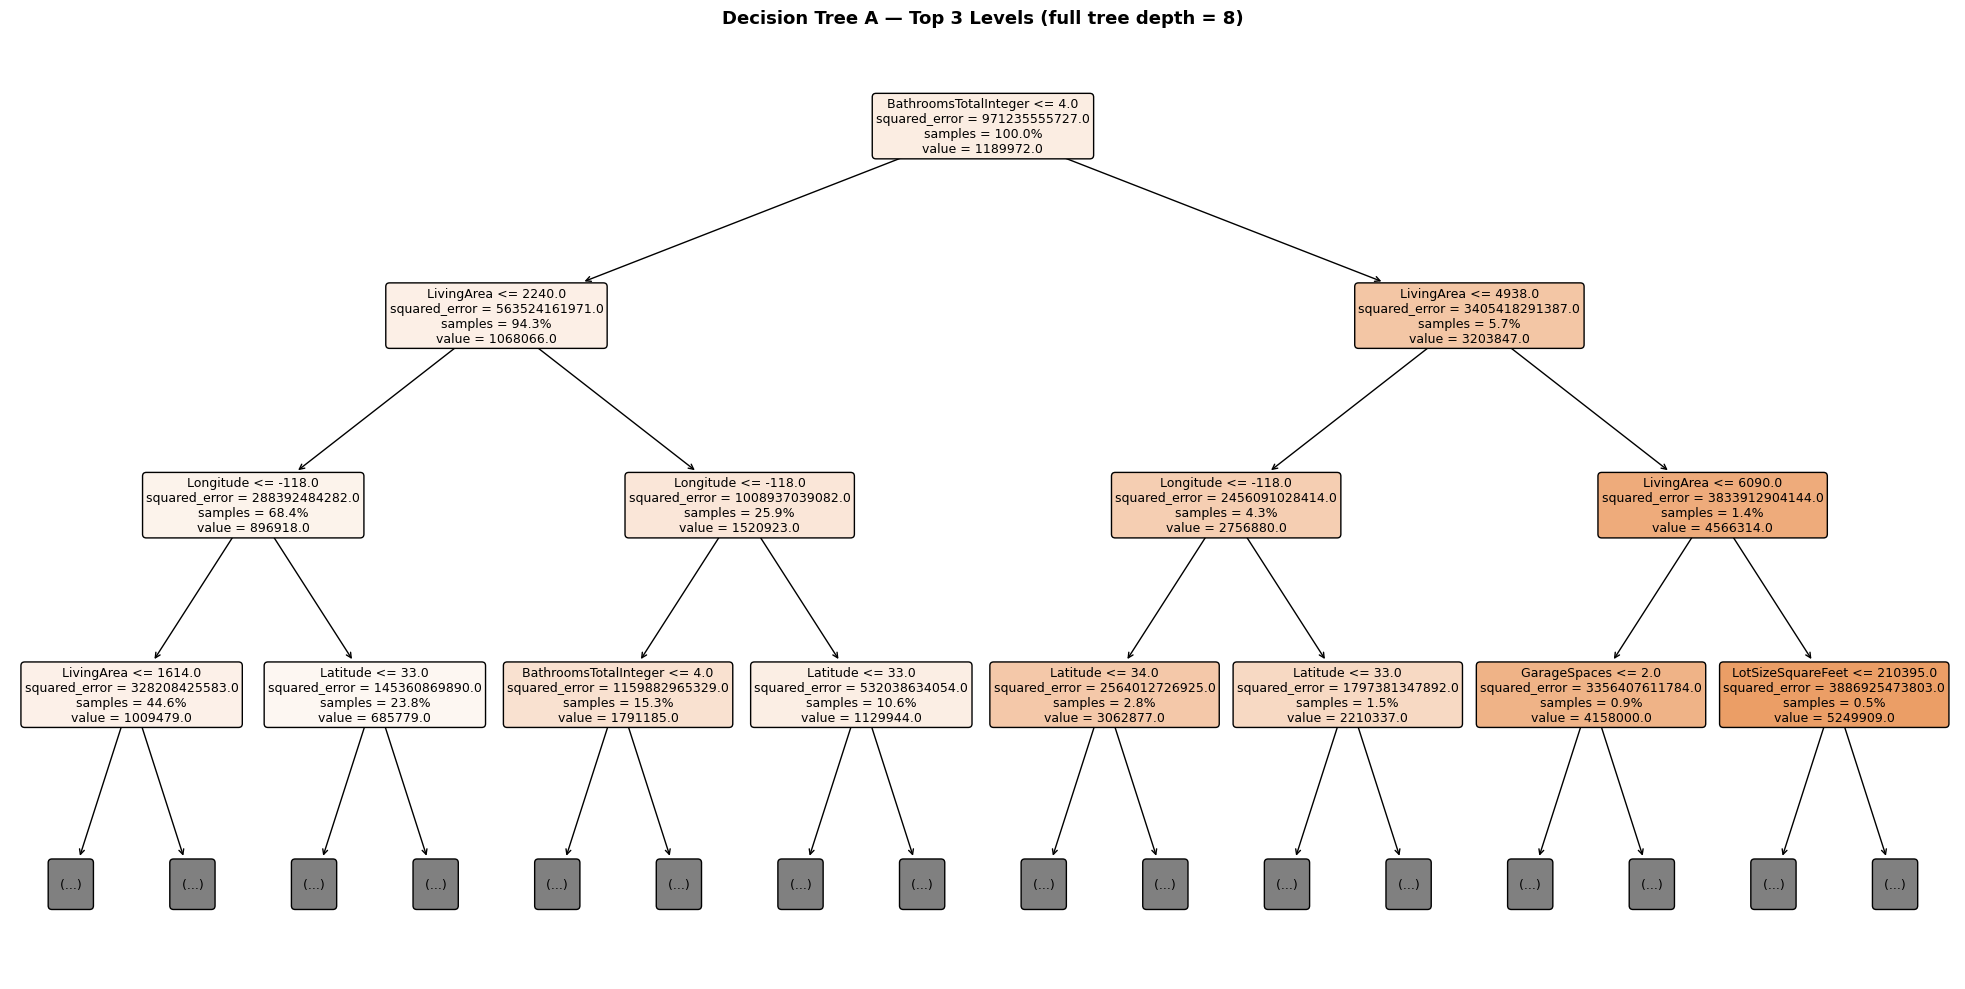

In [10]:
# Visualize the top of the tree (first 3 levels) for interpretability
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=BASELINE_FEATURES,
          filled=True, rounded=True, fontsize=9, ax=ax,
          proportion=True, precision=0)
ax.set_title('Decision Tree A — Top 3 Levels (full tree depth = %d)' % dt_model.get_depth(),
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

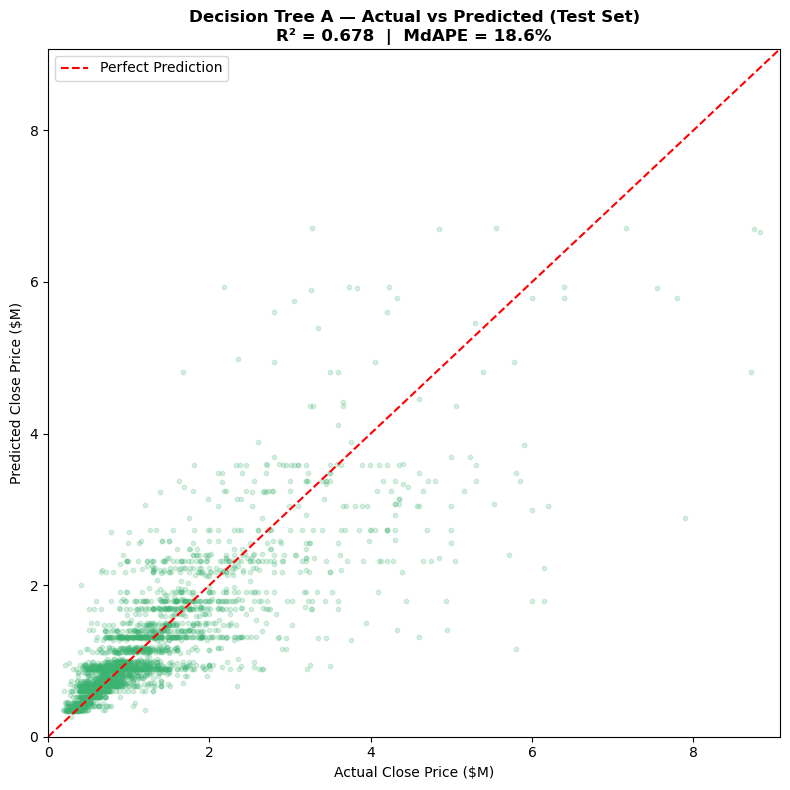

In [11]:
# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(8, 8))
sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)

ax.scatter(y_test.values[sample_idx]/1e6, y_test_pred_dt[sample_idx]/1e6,
           alpha=0.2, s=10, color='mediumseagreen')
lims = [0, max(y_test.max(), y_test_pred_dt.max())/1e6]
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title(f'Decision Tree A — Actual vs Predicted (Test Set)\n'
             f'R² = {dt_test_metrics["r2"]:.3f}  |  MdAPE = {dt_test_metrics["mdape"]:.1f}%',
             fontweight='bold')
ax.set_xlabel('Actual Close Price ($M)')
ax.set_ylabel('Predicted Close Price ($M)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Random Forest Regressor (Random Forest A)

A Random Forest trains many decision trees on bootstrapped samples of the training data
(each tree also sees a random subset of features at each split), then averages their
predictions. This typically **reduces variance** relative to a single tree — individual
trees may overfit to quirks in their particular bootstrap sample, but the average across
many trees smooths that out.

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=200,        # number of trees in the forest
    max_depth=12,            # slightly deeper than the single tree -- variance
                              # reduction from averaging allows more depth per tree
    min_samples_leaf=10,
    random_state=RANDOM_SEED,
    n_jobs=-1                # use all available cores
)
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf  = rf_model.predict(X_test)

print('Random Forest A trained.')
print(f'Number of trees: {rf_model.n_estimators}')

Random Forest A trained.
Number of trees: 200


In [13]:
print('=' * 55)
rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, label='Random Forest A -- TRAIN')
print()
print('=' * 55)
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, label='Random Forest A -- TEST')
print('=' * 55)

Random Forest A -- TRAIN Evaluation:
  R²     : 0.8678
  MAPE   : 15.39%
  MdAPE  : 10.27%   <-- primary metric (robust to skew/outliers)
  MAE    : $185,776

Random Forest A -- TEST Evaluation:
  R²     : 0.8227
  MAPE   : 16.61%
  MdAPE  : 11.23%   <-- primary metric (robust to skew/outliers)
  MAE    : $219,215


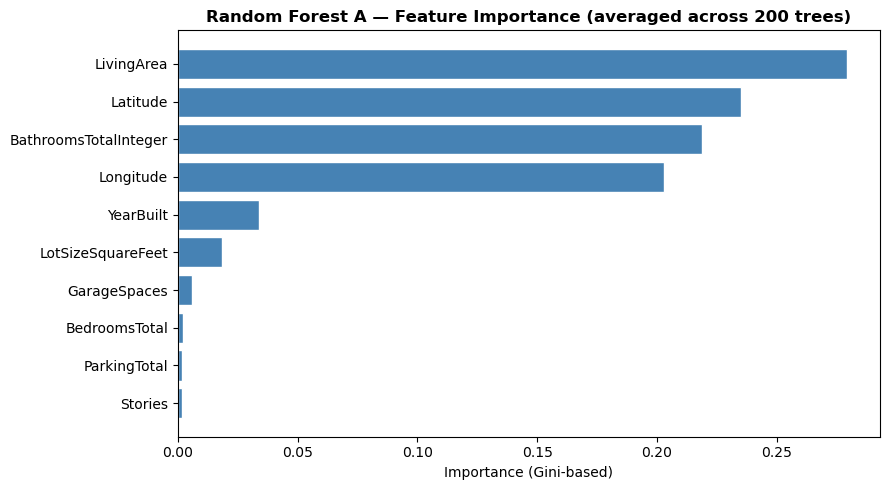

,feature,importance
0,LivingArea,0.279236
8,Latitude,0.234969
3,BathroomsTotalInteger,0.219023
9,Longitude,0.203195
5,YearBuilt,0.033951
1,LotSizeSquareFeet,0.018393
6,GarageSpaces,0.005696
2,BedroomsTotal,0.002001
7,ParkingTotal,0.001877
4,Stories,0.001660


In [14]:
# Feature importance -- averaged across all 200 trees
rf_importance = pd.DataFrame({
    'feature': BASELINE_FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(rf_importance['feature'][::-1], rf_importance['importance'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title('Random Forest A — Feature Importance (averaged across 200 trees)', fontweight='bold')
ax.set_xlabel('Importance (Gini-based)')
plt.tight_layout()
plt.show()

display(rf_importance)

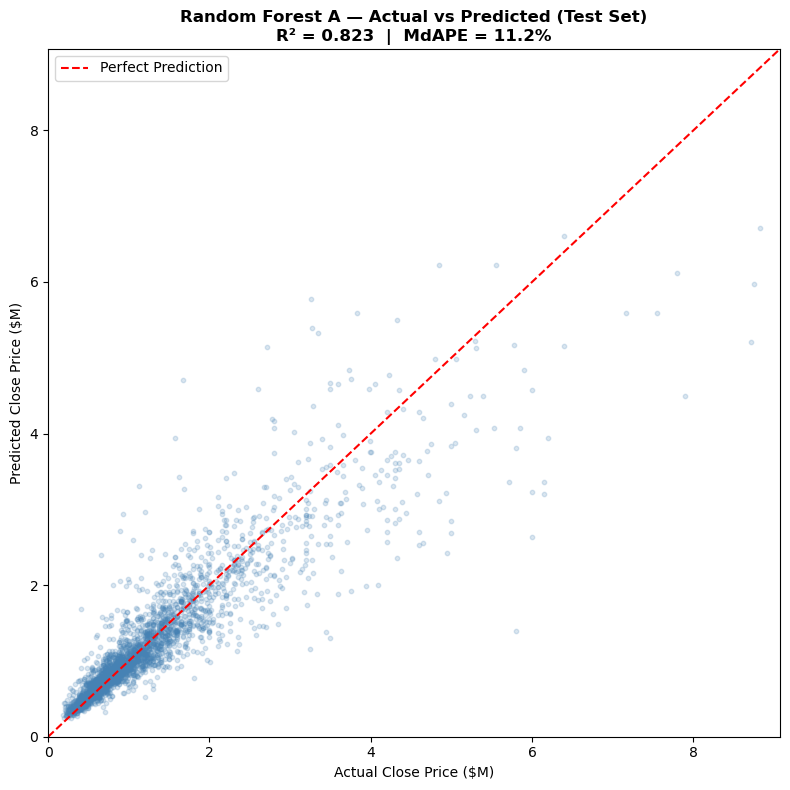

In [15]:
# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test.values[sample_idx]/1e6, y_test_pred_rf[sample_idx]/1e6,
           alpha=0.2, s=10, color='steelblue')
lims = [0, max(y_test.max(), y_test_pred_rf.max())/1e6]
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title(f'Random Forest A — Actual vs Predicted (Test Set)\n'
             f'R² = {rf_test_metrics["r2"]:.3f}  |  MdAPE = {rf_test_metrics["mdape"]:.1f}%',
             fontweight='bold')
ax.set_xlabel('Actual Close Price ($M)')
ax.set_ylabel('Predicted Close Price ($M)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Side-by-Side Comparison: Linear Regression A vs Decision Tree A vs Random Forest A

In [16]:
comparison_df = pd.DataFrame([
    {
        'Model': 'Linear Regression A',
        'R² (test)': lr_a['r2_test'],
        'MAPE (test)': lr_a['mape_test'],
        'MdAPE (test)': lr_a['mdape_test'],
        'MAE (test)': lr_a['mae_test'],
    },
    {
        'Model': 'Decision Tree A',
        'R² (test)': dt_test_metrics['r2'],
        'MAPE (test)': dt_test_metrics['mape'],
        'MdAPE (test)': dt_test_metrics['mdape'],
        'MAE (test)': dt_test_metrics['mae'],
    },
    {
        'Model': 'Random Forest A',
        'R² (test)': rf_test_metrics['r2'],
        'MAPE (test)': rf_test_metrics['mape'],
        'MdAPE (test)': rf_test_metrics['mdape'],
        'MAE (test)': rf_test_metrics['mae'],
    },
])

display(comparison_df)

,Model,R² (test),MAPE (test),MdAPE (test),MAE (test)
0,Linear Regression A,0.473300,43.730000,30.600000,462823.000000
1,Decision Tree A,0.678473,26.315428,18.579082,327164.781343
2,Random Forest A,0.822739,16.610893,11.234653,219214.562892


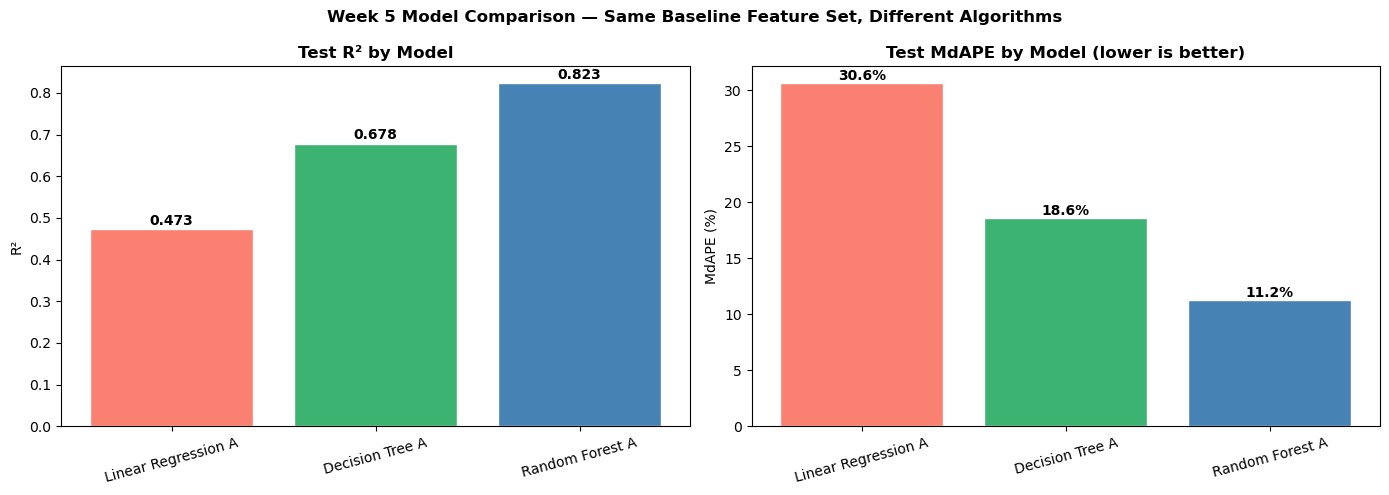

In [17]:
# Grouped bar chart -- R² and MdAPE side by side across all 3 models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['salmon', 'mediumseagreen', 'steelblue']

axes[0].bar(comparison_df['Model'], comparison_df['R² (test)'], color=colors, edgecolor='white')
axes[0].set_title('Test R² by Model', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['R² (test)']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(comparison_df['Model'], comparison_df['MdAPE (test)'], color=colors, edgecolor='white')
axes[1].set_title('Test MdAPE by Model (lower is better)', fontweight='bold')
axes[1].set_ylabel('MdAPE (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['MdAPE (test)']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Week 5 Model Comparison — Same Baseline Feature Set, Different Algorithms',
             fontweight='bold')
plt.tight_layout()
plt.show()

Overfitting check -- large train/test R² gaps signal memorization, not generalization:


,Model,R² Train,R² Test,Train - Test Gap
0,Linear Regression A,0.479700,0.473300,0.006400
1,Decision Tree A,0.713148,0.678473,0.034676
2,Random Forest A,0.867828,0.822739,0.045089


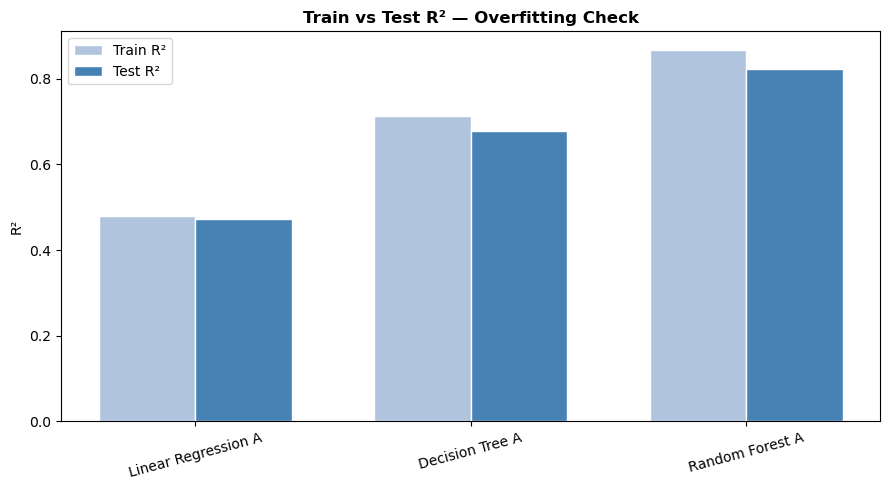

In [18]:
# Train vs test R² -- checks for overfitting across all 3 models
overfit_check = pd.DataFrame([
    {'Model': 'Linear Regression A', 'R² Train': lr_a['r2_train'], 'R² Test': lr_a['r2_test']},
    {'Model': 'Decision Tree A', 'R² Train': dt_train_metrics['r2'], 'R² Test': dt_test_metrics['r2']},
    {'Model': 'Random Forest A', 'R² Train': rf_train_metrics['r2'], 'R² Test': rf_test_metrics['r2']},
])
overfit_check['Train - Test Gap'] = overfit_check['R² Train'] - overfit_check['R² Test']

print('Overfitting check -- large train/test R² gaps signal memorization, not generalization:')
display(overfit_check)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(overfit_check))
width = 0.35
ax.bar(x - width/2, overfit_check['R² Train'], width, label='Train R²', color='lightsteelblue', edgecolor='white')
ax.bar(x + width/2, overfit_check['R² Test'], width, label='Test R²', color='steelblue', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(overfit_check['Model'], rotation=15)
ax.set_title('Train vs Test R² — Overfitting Check', fontweight='bold')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Model Behavior: Strengths & Weaknesses

### Linear Regression A (Week 4 baseline)
**Strengths:**
- Fully interpretable — each coefficient has a direct, additive interpretation
- Fast to train, no hyperparameters to tune
- Stable train/test performance (no overfitting risk with this few features)

**Weaknesses:**
- Cannot capture non-linear relationships (e.g. diminishing returns on `LivingArea` at very
  large sizes) or interactions between features (e.g. `LivingArea` matters differently
  depending on `Latitude`/`Longitude`)
- Treats `Latitude`/`Longitude` as a flat linear gradient across the state, when California
  home prices vary in sharp, non-linear, cluster-like patterns by region
- Sensitive to unscaled features with very different ranges — can produce unstable or
  counter-intuitive coefficients (seen in Week 4: `Stories` had a negative coefficient)

### Decision Tree A
**Strengths:**
- Captures non-linear relationships and feature interactions automatically — no manual
  feature engineering needed to model "LivingArea matters more in some regions than others"
- Naturally handles `Latitude`/`Longitude` as a 2D splitting surface rather than a flat gradient,
  which should meaningfully improve the location signal versus Linear Regression A
- No scaling required — splits are based on feature value thresholds, not magnitudes

**Weaknesses:**
- A single tree is prone to overfitting if depth isn't constrained — it can memorize noise
  in the training data (check the Section 3 overfitting comparison for evidence of this)
- Predictions are piecewise-constant (a step function), not smooth — two nearly-identical
  properties near a split boundary can get very different predictions
- High variance: a small change in the training data can produce a very different tree
  structure, which is exactly the instability Random Forest is designed to fix

### Random Forest A
**Strengths:**
- Averaging across many trees reduces the variance/overfitting problem of a single tree —
  expect a smaller train/test R² gap than Decision Tree A
- Captures the same non-linear location and interaction effects as the single tree, but
  more robustly
- Feature importance is more stable/trustworthy than a single tree's, since it's averaged
  across 200 different bootstrap samples

**Weaknesses:**
- Much less interpretable than either Linear Regression or a single small Decision Tree —
  "the model" is now 200 trees, not one readable structure
- Slower to train and to predict than either simpler alternative
- Still fundamentally limited by the same 10 raw, unencoded features as the other two models
  in this notebook — any remaining gap versus a richer feature set is not a modelling
  limitation, it's an information limitation (see Section 5 Next Steps)

### General Observation Across All Three
All three models in this notebook share the same ceiling: **10 raw fields, no location
encoding beyond lat/lon, no engineered features.** The gap between Random Forest A and
Linear Regression A shows how much of the improvement comes from a better algorithm alone.
Any further large jump (e.g., toward Soyeon's ~0.80 R² result) is much more likely to come
from a richer, better-encoded feature set (Week 6) than from switching models again.

---
## 5. Update Experiment Log

Both new experiments are appended to `experiment_log.csv`, extending the log started in
`03_baseline_model.ipynb`.

In [19]:
new_experiments = pd.DataFrame([
    {
        'experiment_id': 'Decision Tree A',
        'week': 5,
        'model_type': 'Decision Tree Regressor',
        'feature_set': 'Same 10 raw fields as Linear Regression A, no engineering',
        'features_used': ', '.join(BASELINE_FEATURES),
        'imputation_strategy': 'Inherited from 02_preprocessing.ipynb (train-fit medians/modes)',
        'encoding_strategy': 'None -- no categorical fields included',
        'train_window_months': 6,
        'test_month': 'May 2026',
        'r2_train': round(dt_train_metrics['r2'], 4),
        'r2_test': round(dt_test_metrics['r2'], 4),
        'mape_test': round(dt_test_metrics['mape'], 2),
        'mdape_test': round(dt_test_metrics['mdape'], 2),
        'mae_test': round(dt_test_metrics['mae'], 0),
        'notes': f'max_depth=8, min_samples_leaf=20. Same feature set as Linear Regression A -- '
                 f'isolates the effect of model type. See Section 4 for strengths/weaknesses.'
    },
    {
        'experiment_id': 'Random Forest A',
        'week': 5,
        'model_type': 'Random Forest Regressor',
        'feature_set': 'Same 10 raw fields as Linear Regression A, no engineering',
        'features_used': ', '.join(BASELINE_FEATURES),
        'imputation_strategy': 'Inherited from 02_preprocessing.ipynb (train-fit medians/modes)',
        'encoding_strategy': 'None -- no categorical fields included',
        'train_window_months': 6,
        'test_month': 'May 2026',
        'r2_train': round(rf_train_metrics['r2'], 4),
        'r2_test': round(rf_test_metrics['r2'], 4),
        'mape_test': round(rf_test_metrics['mape'], 2),
        'mdape_test': round(rf_test_metrics['mdape'], 2),
        'mae_test': round(rf_test_metrics['mae'], 0),
        'notes': f'n_estimators=200, max_depth=12, min_samples_leaf=10. Same feature set as '
                 f'Linear Regression A and Decision Tree A -- isolates the effect of model type.'
    },
])

experiment_log = pd.concat([experiment_log, new_experiments], ignore_index=True)
experiment_log.to_csv('../deliverables/experiment_log.csv', index=False)

print('Experiment log updated. All experiments so far:')
display(experiment_log[['experiment_id', 'week', 'model_type', 'r2_test', 'mape_test', 'mdape_test']])

Experiment log updated. All experiments so far:


,experiment_id,week,model_type,r2_test,mape_test,mdape_test
0,Linear Regression A,4,Linear Regression,0.4733,43.73,30.60
1,Decision Tree A,5,Decision Tree Regressor,0.6785,26.32,18.58
2,Random Forest A,5,Random Forest Regressor,0.8227,16.61,11.23


---
## 6. Summary & Next Steps

### Results

| Model | R² (test) | MAPE (test) | MdAPE (test) | MAE (test) |
|---|---|---|---|---|
| Linear Regression A | 0.4733 | 43.73% | 30.60% | $462,823 |
| Decision Tree A | 0.6785 | 26.32% | 18.58% | $327,165 |
| **Random Forest A** | **0.8227** | **16.61%** | **11.23%** | **$219,215** |

### Key Takeaway — This Is a Bigger Result Than Expected

**Random Forest A reaches 0.82 test R² using the exact same 10 raw, unencoded fields as
Linear Regression A** — no engineered features, no categorical encoding, no scaling. That's
roughly in line with the ~0.80 R² reported by a teammate's model, achieved here purely by
switching algorithms, before any of the Week 6 feature engineering work.

This confirms the hypothesis from Section 4: **`Latitude`/`Longitude` was never a weak
signal — it was a signal a *linear* model couldn't use.** A tree-based model can split
latitude and longitude into arbitrarily fine, non-linear regions, effectively learning a
location-based valuation surface without needing ZIP code or county as an explicit
categorical feature. The feature importance output backs this up directly: `Latitude` and
`Longitude` combined account for roughly 40% of Random Forest A's total feature importance
— on par with `LivingArea` and `BathroomsTotalInteger`.

### Overfitting Check
- **Linear Regression A:** train/test R² gap of ~0.006 — essentially no overfitting, but
  a low ceiling on both.
- **Decision Tree A:** train/test R² gap of ~0.035 (0.713 -> 0.679) — a single constrained
  tree (`max_depth=8`) generalizes reasonably well, but a piecewise-constant decision
  surface still leaves real accuracy on the table versus the ensemble.
- **Random Forest A:** train/test R² gap of ~0.045 (0.868 -> 0.823) — the biggest raw gap
  of the three, but still modest in relative terms, and by far the best test-set result.
  Averaging across 200 trees is doing real work to keep this from overfitting harder than
  a single deep tree would.

### An Interesting/Unexpected Finding
`BathroomsTotalInteger` ranks as the single most important feature for Decision Tree A
(37% importance) and the third most important for Random Forest A (22%) — ahead of
`BedroomsTotal`, which barely registers (~0%) in both models. This is worth flagging rather
than accepting at face value: it may reflect a genuine market preference (bathroom count is
a strong proxy for renovation quality/luxury tier in CA SFR homes), or it could be picking
up a correlation with something unmeasured (e.g. larger/newer homes tend to have more
bathrooms). Worth a closer look in Week 6 once `BedBathRatio` is reintroduced as an
engineered feature.

### Next Steps (Week 6)
- Introduce engineered features (`PropertyAge`, `BedBathRatio`, `MonthlyHOA`, etc.) from
  `sfr_train.csv`/`sfr_test.csv` and re-run as "B" versions (Linear Regression B, Decision
  Tree B, Random Forest B)
- Introduce encoded location features (`PostalCode_encoded`, `CountyOrParish_encoded`) —
  given how much signal Latitude/Longitude alone already carried in the tree-based models,
  a proper categorical location encoding may push Random Forest B past 0.85+
- Investigate the `BathroomsTotalInteger` importance finding above before assuming it's a
  purely causal relationship
- Begin considering Gradient Boosting (XGBoost/LightGBM) once the engineered feature set is
  in place, per the original Week 7 game plan — likely to further reduce the train/test gap
  seen in Random Forest A

### Deliverables
- `notebooks/04_model_comparison.ipynb` (this notebook)
- `deliverables/experiment_log.csv` — now includes Linear Regression A, Decision Tree A, and Random Forest A